KMEANS CLUSTERING 

In [2]:
import pandas as pd

#IMPORTING PANDAS FOR ANALYSIS AND MANIPULATION

C:\Users\TOUFIQ\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [4]:
df = pd.read_csv('customer_segmentation.csv')

#lOADING DATA

In [5]:
df

#CHECKING DATA

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [244]:
df.columns

#TO CHECK THE COLUMNS

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [240]:
df.shape

#TO CHECK NO OF COLUMNS AND ROWS

(2240, 29)

In [245]:
df.info()

#IT GIVES WHAT TYPE OF DATA LIES ( Dt_Customer CONATIN STR FORMAT)

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [6]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'],dayfirst = True)

#CHANGING THE STR DATA TYPE FROM STR TO DATE

In [7]:
df['Dt_Customer']

0      2012-09-04
1      2014-03-08
2      2013-08-21
3      2014-02-10
4      2014-01-19
          ...    
2235   2013-06-13
2236   2014-06-10
2237   2014-01-25
2238   2014-01-24
2239   2012-10-15
Name: Dt_Customer, Length: 2240, dtype: datetime64[us]

In [10]:
df.info()

#CONVERTED INTO DATE FORMAT

<class 'pandas.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   str           
 3   Marital_Status       2216 non-null   str           
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[us]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   int64       

In [252]:
df.isnull().sum()

#TO CHECK THE NULL VALUE

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [9]:
df.dropna(inplace = True)

##TO DROP THE NULL VALUE (save change permnently with inplace = True )

In [251]:
df.isnull().sum()

#NO NULL VALUE AFTER DROPPING

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [20]:
df.describe()

#DETAIL STSTISTICS

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [25]:
df['Education'].value_counts()

#FINDING THE UNIQUE VALUE OF THE COLUMNS

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [26]:
df['Marital_Status'].value_counts()

##FINDING THE UNIQUE VALUE OF THE COLUMNS

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [18]:
df['Age'] = 2026 - df['Year_Birth']

#CREATING A NEW COLUMN (AGE) BY DOB

In [19]:
df['Age']

#CHECKING THE NEW COLUMN

0       69
1       72
2       61
3       42
4       45
        ..
2235    59
2236    80
2237    45
2238    70
2239    72
Name: Age, Length: 2216, dtype: int64

In [39]:
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# CREATING A NEW COLUMN WITH TOTAL CHILDREN (CONCATINATING KIDHOME + TEENHOME)

In [40]:
df['Total_Children']

#CHECKING THE NEW COLUMN

0       0
1       2
2       0
3       1
4       1
       ..
2235    1
2236    3
2237    0
2238    1
2239    2
Name: Total_Children, Length: 2216, dtype: int64

In [59]:
df.columns

#CHECKING THE NEW COLUMN

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spending', 'Customer_Since'],
      dtype='str')

In [22]:
Spends = ['MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts']

# CREATING A NEW VARIABLE OF SPENDING

In [23]:
df['Total_Spending']  =  df[Spends].sum(axis = 1)

#CREATING A NEW COLUMN OF THEIR SPENDING

In [24]:
df['Total_Spending']

#CHECKING THE NEW COLUMN

0       1529
1         21
2        734
3         48
4        407
        ... 
2235    1094
2236     436
2237    1217
2238     782
2239     151
Name: Total_Spending, Length: 2216, dtype: int64

In [48]:
df['Customer_Since'] = (pd.Timestamp('today') - df['Dt_Customer']).dt.days

#Customer_Tenure (DAYS)

In [49]:
df['Customer_Since']

#CHECKING THE NEW COLUMN

0       4939
1       4389
2       4588
3       4415
4       4437
        ... 
2235    4657
2236    4295
2237    4431
2238    4432
2239    4898
Name: Customer_Since, Length: 2216, dtype: int64

In [29]:
import seaborn as sns

#IMPORTING LIBRARY FOR VISUALIZATION

In [48]:
import matplotlib.pyplot as plt

#IMPORTING LIBRARY FOR VISUALIZATION

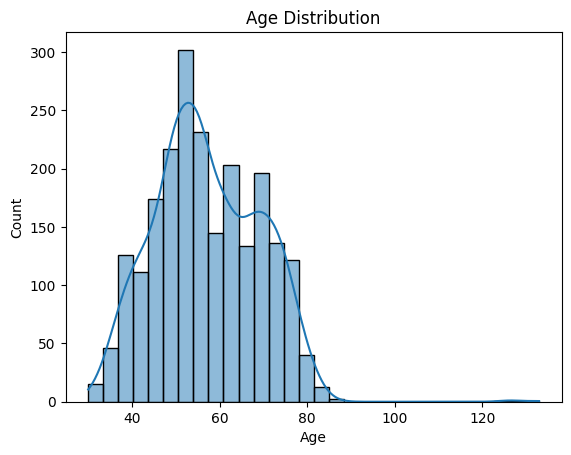

In [57]:
sns.histplot(df['Age'],bins = 30, kde = True)
plt.title('Age Distribution')
plt.show()

#CREATING A HISTOGRAM PLOT WITH AGE 

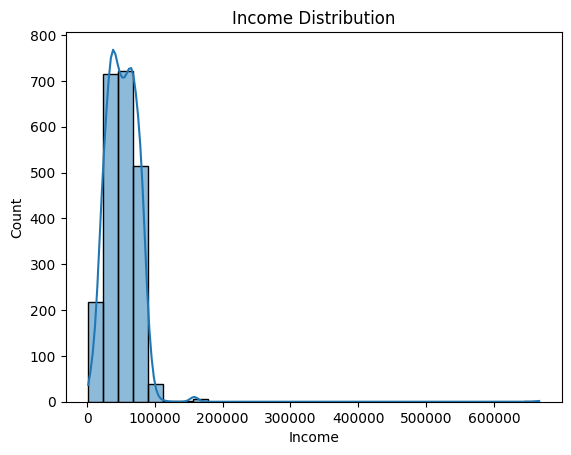

In [58]:
sns.histplot(df['Income'],bins = 30, kde = True)
plt.title('Income Distribution')
plt.show()

#CREATING A HISTOGRAM PLOT WITH INCOME 

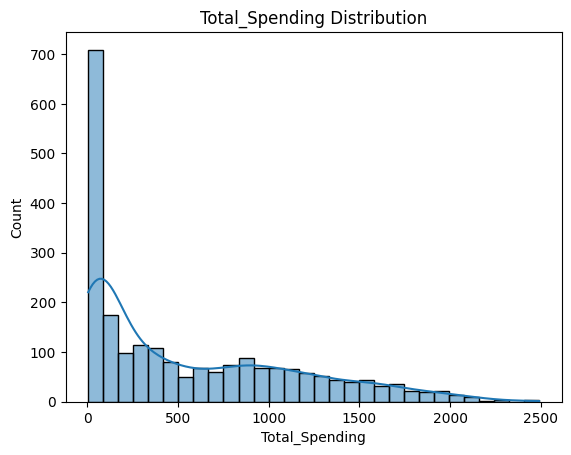

In [61]:
sns.histplot(df['Total_Spending'],bins = 30, kde = True)
plt.title('Total_Spending Distribution')
plt.show()

#CREATING A HISTOGRAM PLOT WITH SPENDING 

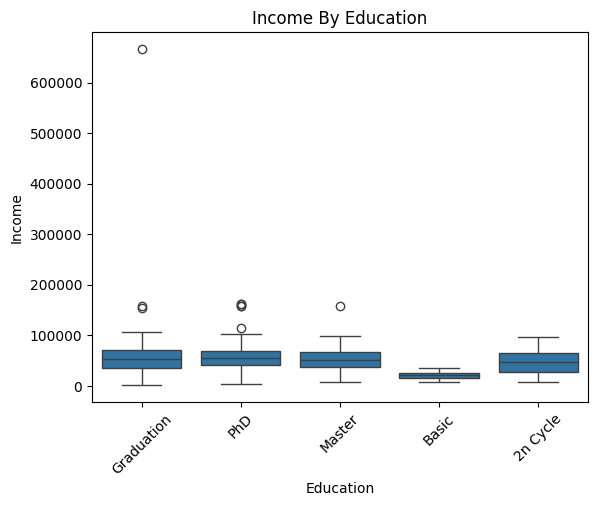

In [64]:
sns.boxplot(x = 'Education',y = 'Income' , data = df )
plt.xticks(rotation = 45)
plt.title('Income By Education')
plt.show()

#CATEGORICAL ANALYSIS BY EDUCATION WITH RESPECT TO INCOME

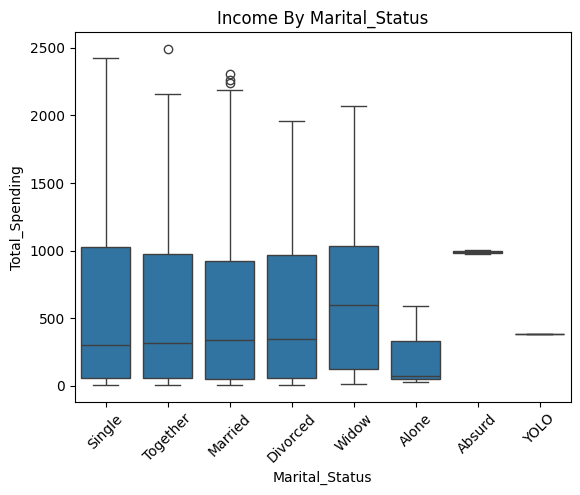

In [66]:
sns.boxplot(x = 'Marital_Status',y = 'Total_Spending' , data = df )
plt.xticks(rotation = 45)
plt.title('Income By Marital_Status')
plt.show()

#CATEGORICAL ANALYSIS BY EDUCATION WITH RESPECT TO SPENDING AND MARITIAL STATUS

In [15]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [26]:
Corr = df[['Income','Age','Recency','Total_Spending','NumStorePurchases','NumWebPurchases']].corr()

#CORRELATION ANALYSIS

In [27]:
Corr

,Income,Age,Recency,Total_Spending,NumStorePurchases,NumWebPurchases
Income,1.000000,0.161791,-0.003970,0.668062,0.529362,0.387878
Age,0.161791,1.000000,0.016295,0.112779,0.127891,0.153051
Recency,-0.003970,0.016295,1.000000,0.019374,-0.000434,-0.005641
Total_Spending,0.668062,0.112779,0.019374,1.000000,0.670327,0.515999
NumStorePurchases,0.529362,0.127891,-0.000434,0.670327,1.000000,0.516240
NumWebPurchases,0.387878,0.153051,-0.005641,0.515999,0.516240,1.000000


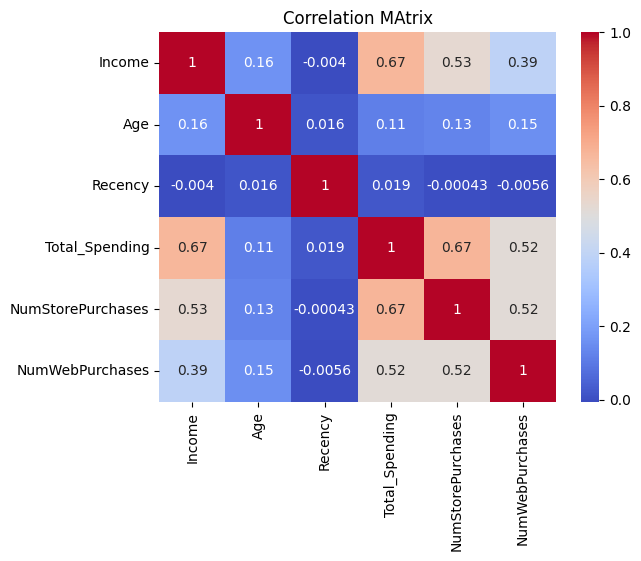

In [31]:
sns.heatmap(Corr , annot = True, cmap = 'coolwarm')
plt.title('Correlation MAtrix')
plt.show()

#CORRELATION MATRIX BY AGE

In [33]:
Pivot = df.pivot_table(values = 'Income', index = 'Education', columns = 'Marital_Status' , aggfunc = 'mean')

#CREATING A PIVOT TABLE

In [34]:
Pivot

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46201.100000,53673.944444,44736.410714,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50800.258741,51322.182927,55758.480702,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52109.009804,58401.545455,NaN
PhD,NaN,35860.0,53096.615385,58138.031579,53314.614583,56041.422414,60288.083333,48432.0


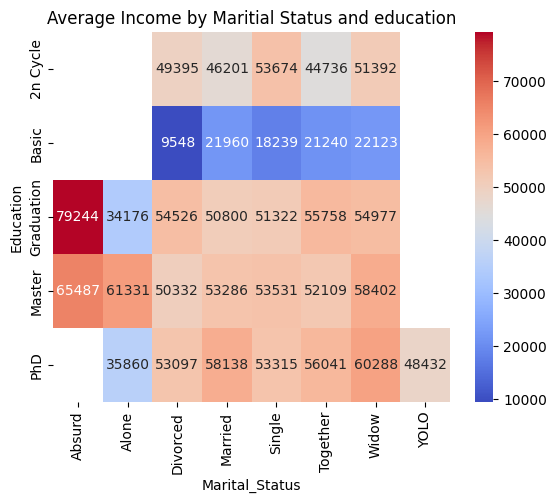

In [88]:
sns.heatmap(Pivot , annot = True, fmt = '.0f',cmap = 'coolwarm')
plt.title('Average Income by Maritial Status and education')
plt.show()

#HEATMAP CHART AVERAGE INCOME MARITIAL STATUS AND EDUCATION

In [36]:
group1 = df.groupby('Education')['Total_Spending'].mean().sort_values(ascending = False)

#Average Spending by  education (GROUP 1)

In [37]:
group1

#CHECKING 

Education
PhD           644.330561
Graduation    571.002688
Master        569.578082
2n Cycle      448.050000
Basic          58.962963
Name: Total_Spending, dtype: float64

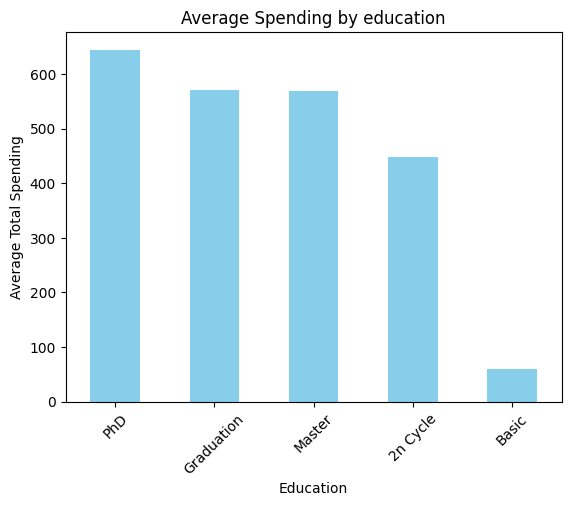

In [38]:
group1.plot(kind ='bar', color = 'skyblue')
plt.title('Average Spending by education')
plt.ylabel('Average Total Spending')
plt.xticks(rotation =45)
plt.show()

#Average Spending by education BY BAR PLOT

In [9]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [39]:
df['CampaignAccept'] = df[['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1','AcceptedCmp2','Response']].sum(axis = 1)

#CREATING A COLUMN WITH CAMPAIGNACCEPT

In [40]:
df['CampaignAccept'].unique()

#CHECKING UNIQUE VALUE

array([1, 0, 3, 2, 4, 5])

In [41]:
df['CampaignAccept'] = df['CampaignAccept'].apply(lambda x: 1 if x > 0 else 0 )

#APPLYING LAMBDA FUNCTION

In [42]:
df['CampaignAccept'].unique()

##CHECKING UNIQUE VALUE

array([1, 0])

In [35]:
df.columns

#CHECK THE COLUMNS

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'CampaignAccept'],
      dtype='str')

In [44]:
group2 = df.groupby('Marital_Status')['CampaignAccept'].mean().sort_values(ascending = False)

#Average Spending by  MARITIAL STATUS AND CAMPAIGNACCEPT (GROUP 2)

In [45]:
group2

#CHECKING

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.342105
Alone       0.333333
Single      0.312102
Divorced    0.297414
Married     0.252042
Together    0.251309
Name: CampaignAccept, dtype: float64

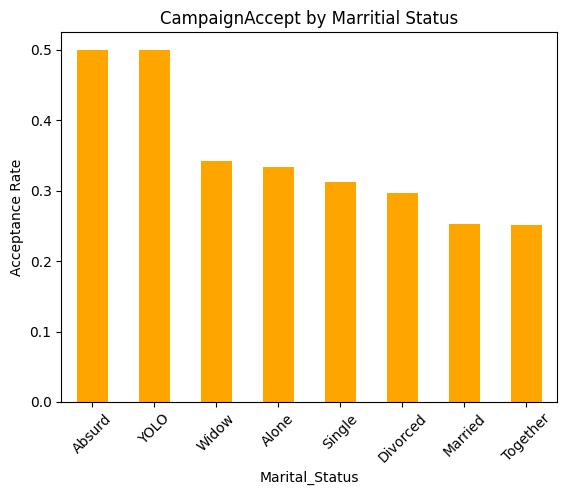

In [49]:
group2.plot(kind = 'bar' , color = 'orange')
plt.title('CampaignAccept by Marritial Status')
plt.ylabel('Acceptance Rate')
plt.xticks(rotation = 45)
plt.show()

#Average Spending by CAMPAIGNACCEPT BY MARITIAL STATUS THROUGH BAR PLOT

In [50]:
bins = [18,30,40,50,60,70,90]

#Average Income by AGE Group

In [51]:
labels = ['18 -29', '30-39','40-49','50-59','60-69','70+']

#GROUPING THE AGE

In [52]:
df['AgeGroup'] = pd.cut(df['Age'], bins = bins ,labels = labels)

#CREATING A NEW COLUMN WITH AGE GROUP

In [53]:
df['AgeGroup']

#CHECKING

0       60-69
1         70+
2       60-69
3       40-49
4       40-49
        ...  
2235    50-59
2236      70+
2237    40-49
2238    60-69
2239      70+
Name: AgeGroup, Length: 2216, dtype: category
Categories (6, str): ['18 -29' < '30-39' < '40-49' < '50-59' < '60-69' < '70+']

In [55]:
group3 = df.groupby('AgeGroup')['Income'].mean()

#GROUPING WITH AGEGROUP AND INCOME

In [58]:
group3

#CHECKING

AgeGroup
18 -29    10960.500000
30-39     47905.475676
40-49     48057.587649
50-59     50479.321534
60-69     55980.030928
70+       58767.083102
Name: Income, dtype: float64

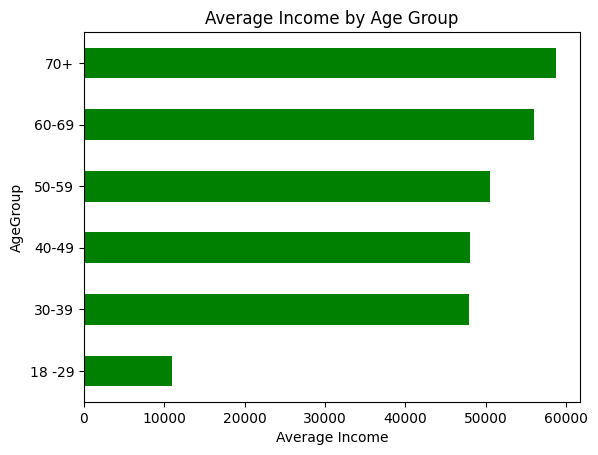

In [59]:
group3.plot(kind = 'barh', color = 'green')
plt.title('Average Income by Age Group')
plt.xlabel('Average Income')
plt.show()

#creating a Horizontal Bar Graph with Age Group and Income

In [60]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Spending', 'CampaignAccept', 'AgeGroup'],
      dtype='str')

In [63]:
feature = ['Age','Income','NumWebPurchases','Recency','NumStorePurchases','NumWebVisitsMonth']

#creating a new variable (feature)

In [70]:
X = df[feature].copy()

#create a Copy of feature and stores in a X variable

In [71]:
df = X.fillna(df.mean(numeric_only=True))

In [72]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#importing Scikit Library and the function

In [73]:
X_scale = scaler.fit_transform(X)

#fit and transform

In [74]:
X_scale

#checking

array([[ 0.98644293,  0.2340627 ,  1.42855332,  0.31053212, -0.55414289,
         0.69323197],
       [ 1.23680074, -0.23455948, -1.12588116, -0.38050944, -1.16951781,
        -0.1315745 ],
       [ 0.31882209,  0.76947764,  1.42855332, -0.79513438,  1.29198186,
        -0.54397773],
       ...,
       [-1.01641959,  0.18809052, -0.76096195,  1.4507507 ,  2.21504423,
         0.28082874],
       [ 1.06989553,  0.67538765,  0.6987149 , -1.41707178,  1.29198186,
        -0.95638097],
       [ 1.23680074,  0.02470453, -0.39604274, -0.31140528, -0.55414289,
         0.69323197]], shape=(2216, 6))

In [75]:
from sklearn.cluster import KMeans

#importing scikit library and Kmeans function

In [76]:
wcss = []

#creating a Empty Variable

In [77]:
for i in range(2, 10):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X_scale)
    wcss.append(kmeans.inertia_)

    #creating a loop statement

In [78]:
wcss

#checking

[9408.075537985593,
 8588.657397136742,
 7551.536466838508,
 6949.230588349026,
 6382.052304755803,
 6061.8007196455565,
 5418.836876885933,
 5493.5232940017895]

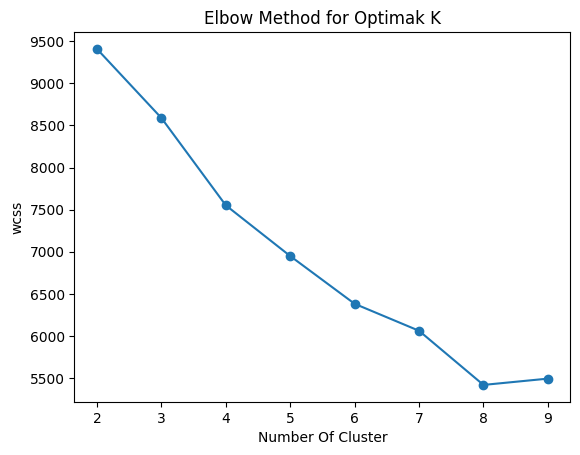

In [79]:
plt.plot(range(2,10),wcss,marker = 'o')
plt.title('Elbow Method for Optimak K')
plt.xlabel('Number Of Cluster')
plt.ylabel('wcss')
plt.show()

#checking the Elbow mrthod for clustering

In [81]:
kmeans = KMeans (n_clusters = 6)
df['Clusters'] = kmeans.fit_predict(X_scale)

#predicting the cluster

In [83]:
df.head()

#checking

,Age,Income,NumWebPurchases,Recency,NumStorePurchases,NumWebVisitsMonth,Clusters
0,69,58138.0,8,58,4,7,5
1,72,46344.0,1,38,2,5,0
2,61,71613.0,8,26,10,4,1
3,42,26646.0,2,26,4,6,0
4,45,58293.0,5,94,6,5,2


In [85]:
cluster_summary = df.groupby('Clusters')[feature].mean()

#grouping the clusters with means and storing in a variable 

In [87]:
cluster_summary

#checking

,Age,Income,NumWebPurchases,Recency,NumStorePurchases,NumWebVisitsMonth
Clusters,,,,,,
0,52.702170,33169.901381,2.074951,24.187377,3.132150,6.591716
1,65.541045,68127.720149,5.022388,17.873134,8.399254,3.667910
2,53.960825,34102.247423,2.325773,74.298969,3.247423,6.853608
3,45.958042,78038.188811,4.597902,52.276224,8.930070,2.573427
4,69.898601,67035.902098,3.825175,73.559441,6.891608,3.062937
5,60.205729,59046.250000,8.119792,50.872396,7.593750,6.578125


In [217]:
df['Clusters'].value_counts()

#checking the clusters

Clusters
4    461
2    419
0    363
3    332
5    331
1    310
Name: count, dtype: int64

In [90]:
from sklearn.decomposition import PCA

#Importing Principal Component analysis from scikit learn

In [91]:
pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scale)
df['PCA1'],df['PCA2'] =pca_data[:,0], pca_data[:,1]

#adding the data in PCA

In [92]:
pca_data

#cheking

array([[ 0.31746063, -0.23571531],
       [-0.91363477,  0.20718213],
       [ 2.01196157, -1.04764018],
       ...,
       [ 0.66328605,  1.22184852],
       [ 1.99426398, -1.22119223],
       [-0.50019401, -0.22709238]], shape=(2216, 2))

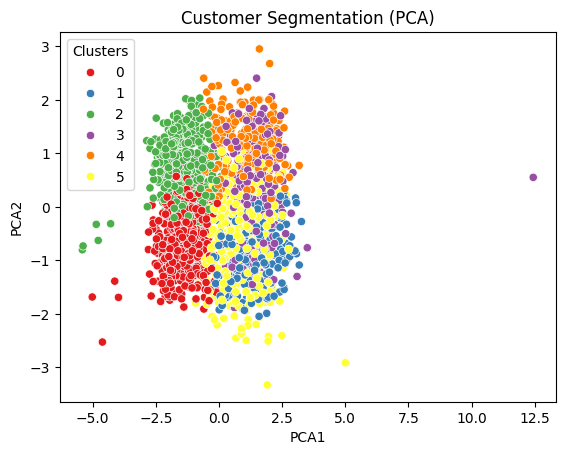

In [93]:
sns.scatterplot(x = 'PCA1', y = 'PCA2' ,hue = 'Clusters', data = df, palette = 'Set1')
plt.title('Customer Segmentation (PCA)')
plt.show()

#cxreating a Scatter plot with the clusters by customer segment PCA

In [94]:
cluster_summary

#checking

,Age,Income,NumWebPurchases,Recency,NumStorePurchases,NumWebVisitsMonth
Clusters,,,,,,
0,52.702170,33169.901381,2.074951,24.187377,3.132150,6.591716
1,65.541045,68127.720149,5.022388,17.873134,8.399254,3.667910
2,53.960825,34102.247423,2.325773,74.298969,3.247423,6.853608
3,45.958042,78038.188811,4.597902,52.276224,8.930070,2.573427
4,69.898601,67035.902098,3.825175,73.559441,6.891608,3.062937
5,60.205729,59046.250000,8.119792,50.872396,7.593750,6.578125


In [95]:
import joblib
joblib.dump(kmeans ,'kmeans_model.pkl')
joblib.dump(scaler,'scaler.pkl')


['scaler.pkl']

END